In [1]:
#import libraries
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve,mean_absolute_error,root_mean_squared_error,r2_score


c:\Users\Dilsh\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
#configure settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
sns.set_theme(style='darkgrid')
pd.set_option('display.float_format', lambda x: '%.2f' % x)

plt.rcParams.update({
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10 ,
})

csv_path="../Data_set/housing.csv"
Target_col="median_house_value"

In [3]:
#lode data set
df=pd.read_csv(csv_path)

***Columns Details:***
1. longitude: A measure of how far west a house is; a higher value is farther west

2. latitude: A measure of how far north a house is; a higher value is farther north

3. housingMedianAge: Median age of a house within a block; a lower number is a newer building

4. totalRooms: Total number of rooms within a block

5. totalBedrooms: Total number of bedrooms within a block

6. population: Total number of people residing within a block

7. households: Total number of households, a group of people residing within a home unit, for a block

8. medianIncome: Median income for households within a block of houses (measured in tens of thousands of US Dollars)

9. medianHouseValue: Median house value for households within a block (measured in US Dollars)

10. oceanProximity: Location of the house w.r.t ocean/sea




**EDA**

In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.7 MB


In [5]:
#identify numerical and categorical columns
num_cols=df.select_dtypes(include=np.number).columns.tolist()
cat_cols=df.select_dtypes(include=object).columns.tolist()

print("Numerical columns:", num_cols, "\n\nCategorical columns:", cat_cols)


Numerical columns: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value'] 

Categorical columns: ['ocean_proximity']


C:\Users\Dilsh\AppData\Local\Temp\ipykernel_12692\796803347.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols=df.select_dtypes(include=object).columns.tolist()


In [6]:
#missing values
df.isnull().sum()


longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [7]:
for col in df.columns:
    print(df[col].value_counts().head(10))


longitude
-118.31    162
-118.30    160
-118.29    148
-118.27    144
-118.32    142
-118.28    141
-118.35    140
-118.36    138
-118.19    135
-118.37    128
Name: count, dtype: int64
latitude
34.06    244
34.05    236
34.08    234
34.07    231
34.04    221
34.09    212
34.02    208
34.10    203
34.03    193
33.93    181
Name: count, dtype: int64
housing_median_age
52.00    1273
36.00     862
35.00     824
16.00     771
17.00     698
34.00     689
26.00     619
33.00     615
18.00     570
25.00     566
Name: count, dtype: int64
total_rooms
1527.00    18
1613.00    17
1582.00    17
2127.00    16
1471.00    15
2053.00    15
1717.00    15
1607.00    15
1722.00    15
1703.00    15
Name: count, dtype: int64
total_bedrooms
280.00    55
331.00    51
345.00    50
393.00    49
343.00    49
348.00    48
328.00    48
394.00    48
309.00    47
272.00    47
Name: count, dtype: int64
population
891.00     25
1227.00    24
761.00     24
850.00     24
1052.00    24
825.00     23
999.00     22
1005.0

In [8]:
df.duplicated().sum()   


np.int64(0)

In [9]:
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
longitude,20640.00,-119.57,2.00,-124.35,-121.80,-118.49,-118.01,-114.31
latitude,20640.00,35.63,2.14,32.54,33.93,34.26,37.71,41.95
housing_median_age,20640.00,28.64,12.59,1.00,18.00,29.00,37.00,52.00
total_rooms,20640.00,2635.76,2181.62,2.00,1447.75,2127.00,3148.00,39320.00
total_bedrooms,20433.00,537.87,421.39,1.00,296.00,435.00,647.00,6445.00
population,20640.00,1425.48,1132.46,3.00,787.00,1166.00,1725.00,35682.00
households,20640.00,499.54,382.33,1.00,280.00,409.00,605.00,6082.00
median_income,20640.00,3.87,1.90,0.50,2.56,3.53,4.74,15.00
median_house_value,20640.00,206855.82,115395.62,14999.00,119600.00,179700.00,264725.00,500001.00


**Data Visualization**

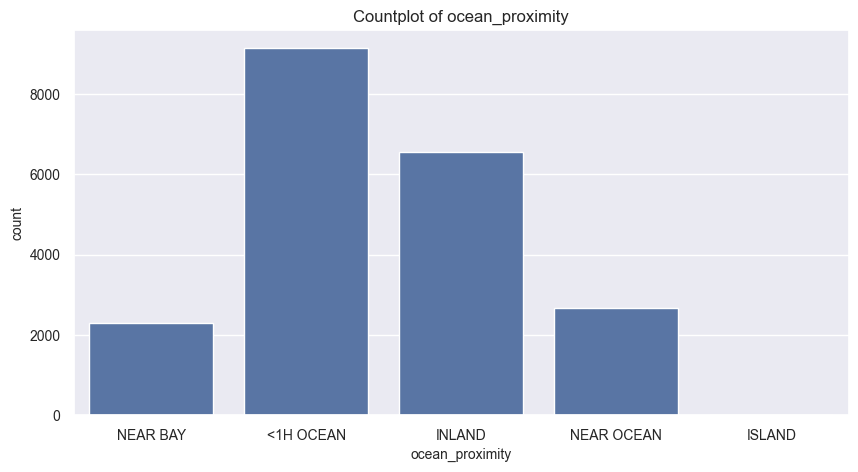

In [10]:
# countplot for categorical columns
for col in cat_cols:
    plt.figure(figsize=(10, 5))
    sns.countplot(data=df, x=col)
    plt.title(f'Countplot of {col}')
    plt.show()


ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


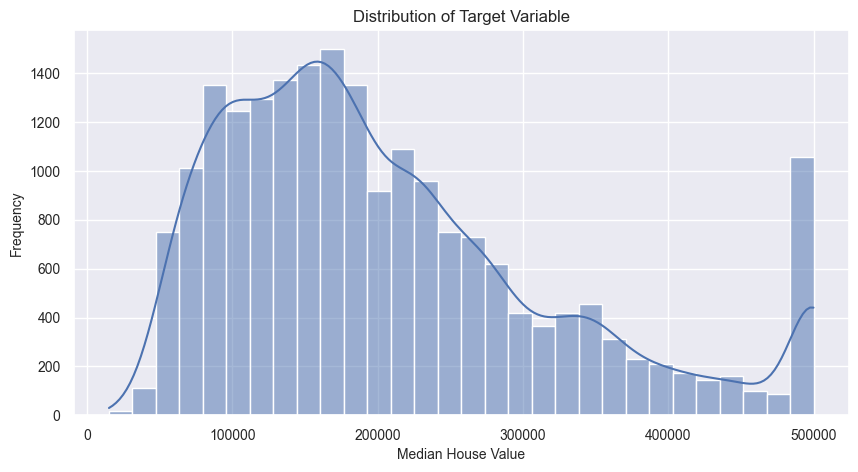

In [11]:
for col in cat_cols:
    print(df[col].value_counts().head(10))
# target columns distribution
plt.figure(figsize=(10, 5))
sns.histplot(df[Target_col], bins=30, kde=True)
plt.title('Distribution of Target Variable')
plt.xlabel('Median House Value')
plt.ylabel('Frequency')
plt.show()

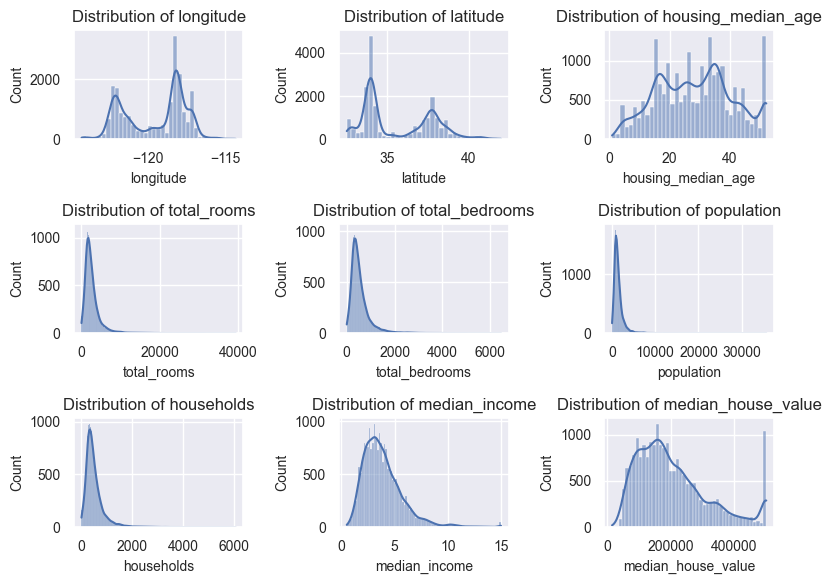

In [12]:
df[Target_col].value_counts()
# histrogram plot distributions
fig,axes=plt.subplots(3,3, figsize=(8,6))  
axes=axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col],kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

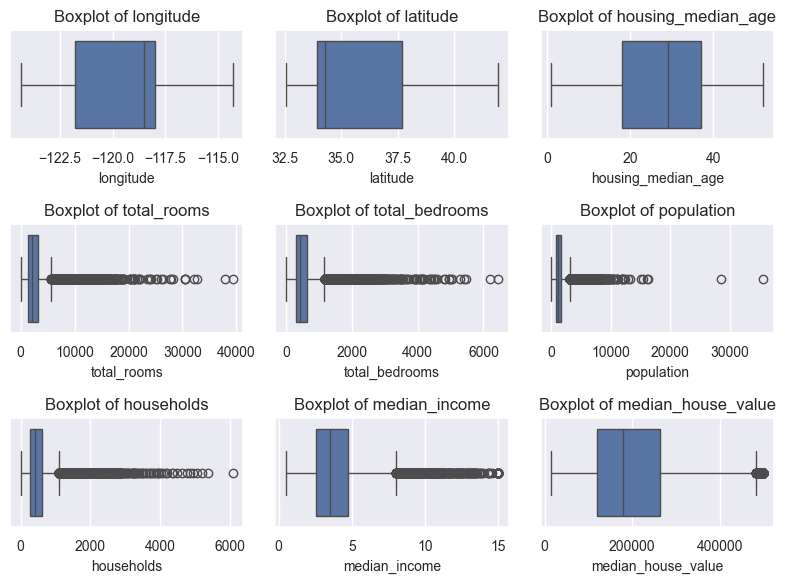

In [13]:
#outliers anlysis 
fig, axes=plt.subplots(3,3, figsize=(8,6))
axes=axes.flatten()
for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

In [14]:
# get outliers sum eatch column
for col in num_cols:
    Q1=df[col].quantile(0.25)
    Q3=df[col].quantile(0.75)
    IQR=Q3-Q1
    lower_bound=Q1-1.5*IQR
    upper_bound=Q3+1.5*IQR
    outliers=df[(df[col]<lower_bound) | (df[col]>upper_bound)]
    print(f'Number of outliers in {col}: {outliers.shape[0]}')


Number of outliers in longitude: 0
Number of outliers in latitude: 0
Number of outliers in housing_median_age: 0
Number of outliers in total_rooms: 1287
Number of outliers in total_bedrooms: 1271
Number of outliers in population: 1196
Number of outliers in households: 1220
Number of outliers in median_income: 681
Number of outliers in median_house_value: 1071



Correlation with target variable:
median_house_value    1.00
median_income         0.69
total_rooms           0.13
housing_median_age    0.11
households            0.07
total_bedrooms        0.05
population           -0.02
longitude            -0.05
latitude             -0.14
Name: median_house_value, dtype: float64


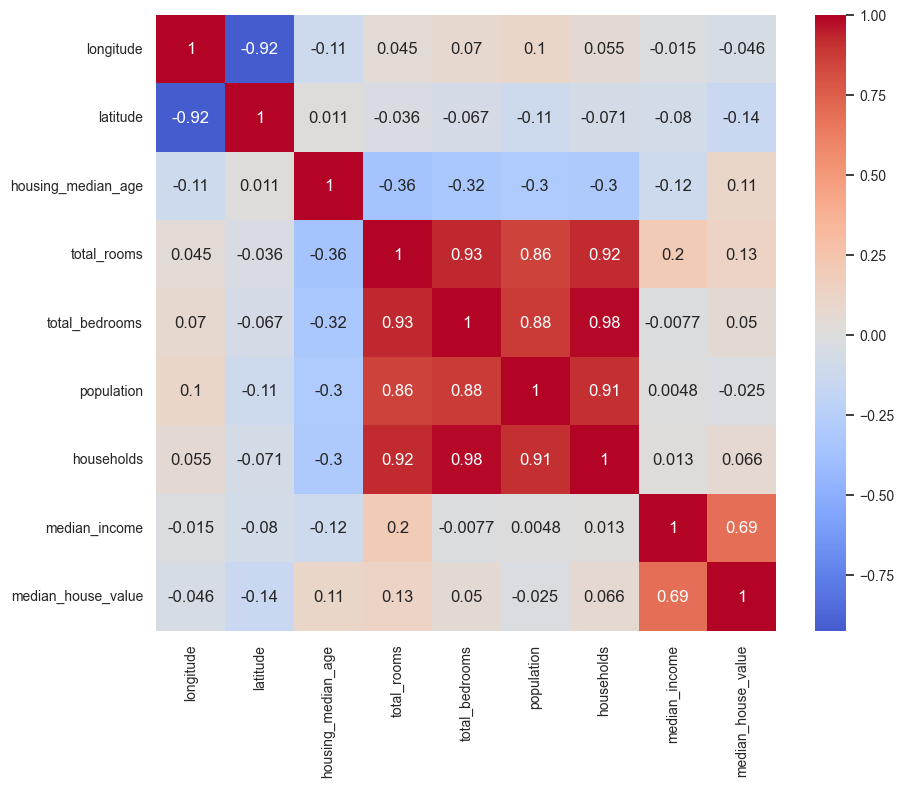

In [15]:
#identify the highly correlated features
plt.figure(figsize=(10, 8))
sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    cmap='coolwarm',
    center=0,
)
#correlation with target variable
corr_with_traget=df[num_cols].corr()[Target_col].sort_values(ascending=False)
print("\nCorrelation with target variable:")
print(corr_with_traget)


**Data Preprocessing**

In [16]:
#saparete features and target variable
x=df.drop(Target_col,axis=1 )


In [17]:
y=df[Target_col]


In [18]:
print(x.head())
print(y.head())


   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88               41.00       880.00          129.00   
1    -122.22     37.86               21.00      7099.00         1106.00   
2    -122.24     37.85               52.00      1467.00          190.00   
3    -122.25     37.85               52.00      1274.00          235.00   
4    -122.25     37.85               52.00      1627.00          280.00   

   population  households  median_income ocean_proximity  
0      322.00      126.00           8.33        NEAR BAY  
1     2401.00     1138.00           8.30        NEAR BAY  
2      496.00      177.00           7.26        NEAR BAY  
3      558.00      219.00           5.64        NEAR BAY  
4      565.00      259.00           3.85        NEAR BAY  
0   452600.00
1   358500.00
2   352100.00
3   341300.00
4   342200.00
Name: median_house_value, dtype: float64


In [19]:
# split data into training and testing sets
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

print("Training set shape:", x_train.shape, y_train.shape)
print("Testing set shape:", x_test.shape, y_test.shape)


Training set shape: (16512, 9) (16512,)
Testing set shape: (4128, 9) (4128,)


In [22]:
#get this data pkl file train and test data

import joblib
joblib.dump(x_train, '../models/x_train.pkl')
joblib.dump(x_test, '../models/x_test.pkl')
joblib.dump(y_train, '../models/y_train.pkl')
joblib.dump(y_test, '../models/y_test.pkl')

['../models/y_test.pkl']

preprocessing pipeline

In [20]:
numaric_features = x_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = x_train.select_dtypes(exclude=np.number).columns.tolist()
print("Numerical features:", numaric_features)
print("Categorical features:", categorical_features)

Numerical features: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']
Categorical features: ['ocean_proximity']


In [21]:
# categorical and numaric transformer
numaric_transformer=Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  
    ('scaler', StandardScaler())    
])

categorical_transformer=Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
]) 

#preproces pipeline
preprocessor=ColumnTransformer(transformers=[
    ('num', numaric_transformer, numaric_features),
    ('cat', categorical_transformer, categorical_features)
])